# 16 - Autoencoders in PyTorch

This notebook extends the PyTorch tabular workflow from Notebook 15 into unsupervised representation learning. EnergyTypeNet is the primary dataset throughout the notebook. The main practical use case is anomaly detection: an autoencoder trained to reconstruct normal building patterns should produce larger reconstruction errors for unusual buildings.

The notebook covers vanilla autoencoders, denoising autoencoders, variational autoencoders, bottleneck-size studies and autoencoder latent features for downstream classification.


## 0. Setup

EnergyTypeNet has five numeric features plus `Day of Week`. For autoencoder reconstruction, `Day of Week` is encoded as `Is Weekend`, giving a six-feature tabular input:

`Input(6) -> Dense(32) -> Dense(16) -> Latent(k) -> Dense(16) -> Dense(32) -> Output(6)`


In [1]:
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import CLASSES, LABEL_MAP, load_raw

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = PROJECT_ROOT / 'data'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('PyTorch:', torch.__version__)
print('Device:', DEVICE)


PyTorch: 2.12.1+cpu
Device: cpu


In [2]:
def make_autoencoder_frame(df):
    frame = pd.DataFrame({
        'Energy Consumption': df['Energy Consumption'],
        'Square Footage': df['Square Footage'],
        'Number of Occupants': df['Number of Occupants'],
        'Appliances Used': df['Appliances Used'],
        'Average Temperature': df['Average Temperature'],
        'Is Weekend': (df['Day of Week'] == 'Weekend').astype(float),
    })
    return frame


train_df = load_raw(DATA_DIR / 'train_energy_data.csv')
test_df = load_raw(DATA_DIR / 'test_energy_data.csv')

feature_names = list(make_autoencoder_frame(train_df).columns)
y_train_labels = train_df['Building Type'].to_numpy()
y_test_labels = test_df['Building Type'].to_numpy()
y_train = train_df['Building Type'].map(LABEL_MAP).to_numpy()
y_test = test_df['Building Type'].map(LABEL_MAP).to_numpy()

X_train_raw = make_autoencoder_frame(train_df).to_numpy(dtype=float)
X_test_raw = make_autoencoder_frame(test_df).to_numpy(dtype=float)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32, device=DEVICE)

train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=128, shuffle=False)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Features:', feature_names)


Train shape: (1000, 6)
Test shape: (100, 6)
Features: ['Energy Consumption', 'Square Footage', 'Number of Occupants', 'Appliances Used', 'Average Temperature', 'Is Weekend']


## 1. What Is an Autoencoder?

An autoencoder learns to reconstruct its own input. The encoder compresses the input into a lower-dimensional latent vector, and the decoder reconstructs the original input from that compressed representation.

```text
Input(6)
  -> Dense(32)
  -> Dense(16)
  -> Latent(3)
  -> Dense(16)
  -> Dense(32)
  -> Output(6)
```

The reconstruction loss is usually mean squared error:

`MSE = mean((x - x_hat)^2)`

The bottleneck forces compression. If the latent dimension is too small, reconstruction quality drops. If it is too large, the autoencoder may simply copy the input without learning a useful representation.


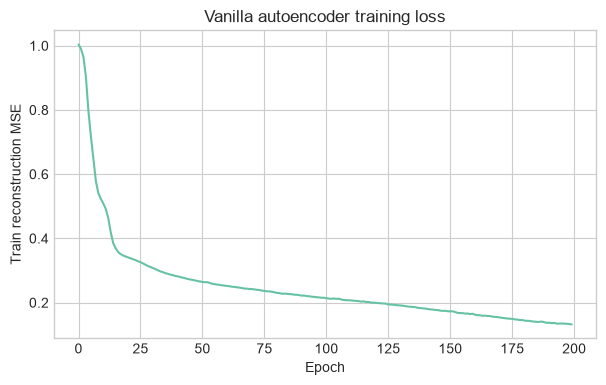

Final train MSE: 0.13118368
Final test MSE: 0.19655159


In [3]:
class BaseAutoencoder(nn.Module):
    def __init__(self, input_dim=6, latent_dim=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    def encode(self, x):
        return self.encoder(x)


def reconstruction_errors(model, X_tensor):
    model.eval()
    with torch.no_grad():
        reconstructed = model(X_tensor)
        errors = ((X_tensor - reconstructed) ** 2).mean(dim=1)
    return errors.detach().cpu().numpy(), reconstructed.detach().cpu().numpy()


def train_autoencoder(model, loader, n_epochs=200, lr=1e-3, noise_std=None):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    for _ in range(n_epochs):
        model.train()
        total = 0.0
        n = 0
        for (xb,) in loader:
            target = xb
            inputs = xb
            if noise_std is not None:
                inputs = xb + torch.randn_like(xb) * noise_std
            optimizer.zero_grad()
            reconstructed = model(inputs)
            loss = criterion(reconstructed, target)
            loss.backward()
            optimizer.step()
            total += loss.item() * len(xb)
            n += len(xb)
        history.append(total / n)
    return history


ae = BaseAutoencoder(input_dim=X_train.shape[1], latent_dim=3)
ae_history = train_autoencoder(ae, train_loader, n_epochs=200, lr=1e-3)

plt.figure(figsize=(7, 4))
plt.plot(ae_history)
plt.xlabel('Epoch')
plt.ylabel('Train reconstruction MSE')
plt.title('Vanilla autoencoder training loss')
plt.show()

train_errors, _ = reconstruction_errors(ae, X_train_tensor)
test_errors, X_test_recon = reconstruction_errors(ae, X_test_tensor)
print('Final train MSE:', train_errors.mean())
print('Final test MSE:', test_errors.mean())


**Observation:** The vanilla autoencoder converged to a train MSE of about `0.131` and a test MSE of about `0.197`. The higher test error is expected because the model is reconstructing unseen buildings from a compressed latent representation, not memorizing the input table.


## 2. Reconstruction Quality on EnergyTypeNet


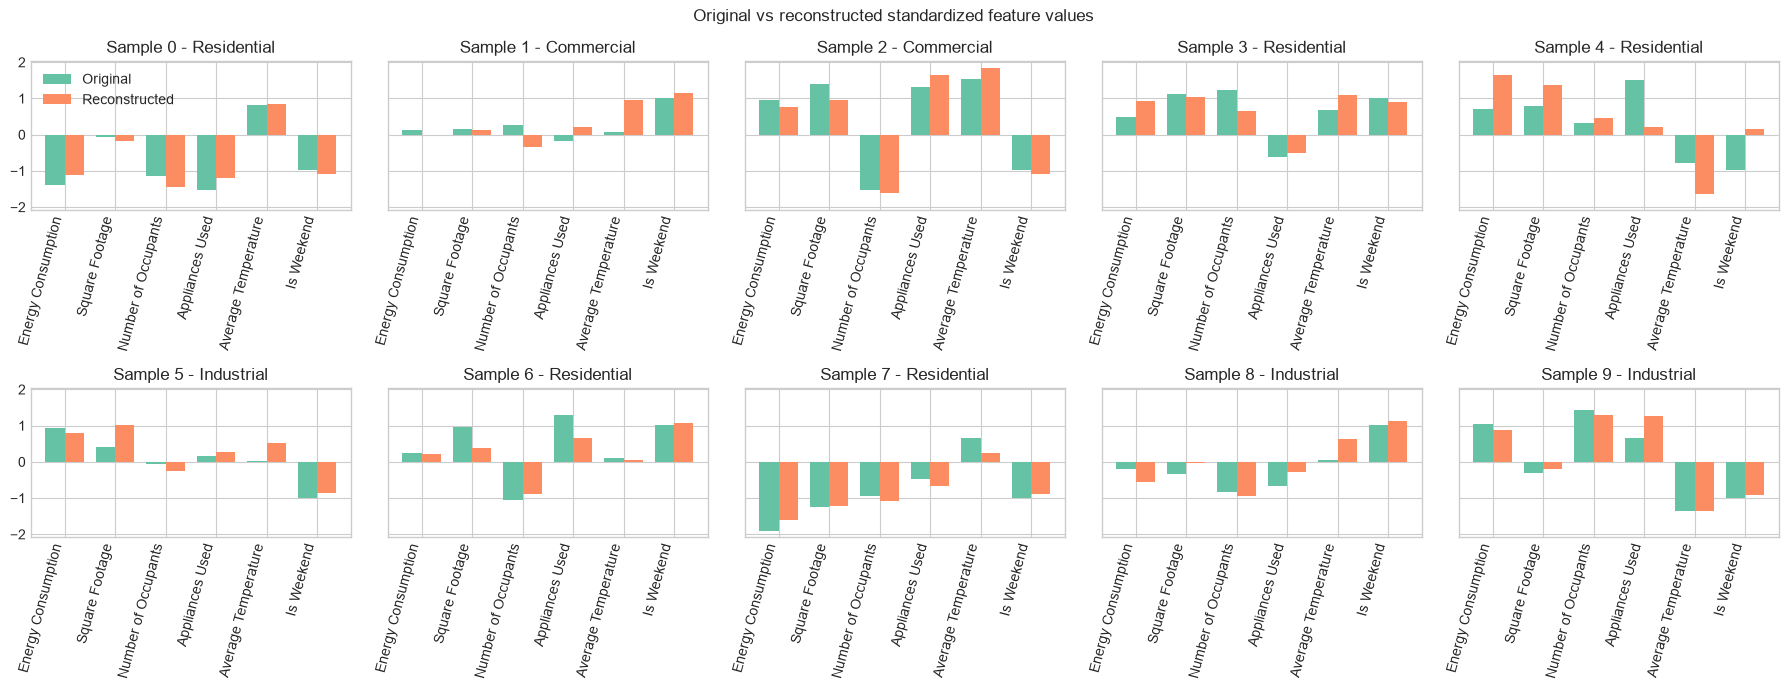

,feature,mse
3,Appliances Used,0.320534
4,Average Temperature,0.268466
2,Number of Occupants,0.207620
0,Energy Consumption,0.159824
5,Is Weekend,0.114636
1,Square Footage,0.108230


,sample,building_type,energy_consumption,reconstruction_error
51,51,Residential,4294.59,1.791904
60,60,Residential,2351.97,0.839988
4,4,Residential,4820.59,0.825879
91,91,Residential,3977.63,0.811879
80,80,Residential,3980.90,0.706661
16,16,Industrial,4987.52,0.642356
73,73,Commercial,4510.20,0.566511
38,38,Residential,2405.34,0.559751
70,70,Industrial,4103.39,0.545862
66,66,Industrial,4575.58,0.493865


In [4]:
sample_count = 10
original = X_test[:sample_count]
reconstructed = X_test_recon[:sample_count]

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
for idx, ax in enumerate(axes.ravel()):
    x_pos = np.arange(len(feature_names))
    width = 0.38
    ax.bar(x_pos - width / 2, original[idx], width, label='Original')
    ax.bar(x_pos + width / 2, reconstructed[idx], width, label='Reconstructed')
    ax.set_title(f'Sample {idx} - {y_test_labels[idx]}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(feature_names, rotation=75, ha='right')
axes[0, 0].legend()
plt.suptitle('Original vs reconstructed standardized feature values')
plt.tight_layout()
plt.show()

feature_mse = ((X_test - X_test_recon) ** 2).mean(axis=0)
feature_mse_df = pd.DataFrame({
    'feature': feature_names,
    'mse': feature_mse,
}).sort_values('mse', ascending=False)
display(feature_mse_df)

sample_error_df = pd.DataFrame({
    'sample': np.arange(len(X_test)),
    'building_type': y_test_labels,
    'energy_consumption': test_df['Energy Consumption'].to_numpy(),
    'reconstruction_error': test_errors,
}).sort_values('reconstruction_error', ascending=False)
display(sample_error_df.head(10))


**Observation:** `Appliances Used` is the hardest feature to reconstruct, followed by `Average Temperature` and `Number of Occupants`. The highest-error samples are mostly Residential buildings with unusual energy patterns, which is useful: reconstruction error is not simply copying the class label, it is identifying individual rows that look unusual in feature space.


## 3. Latent Space Visualization on EnergyTypeNet


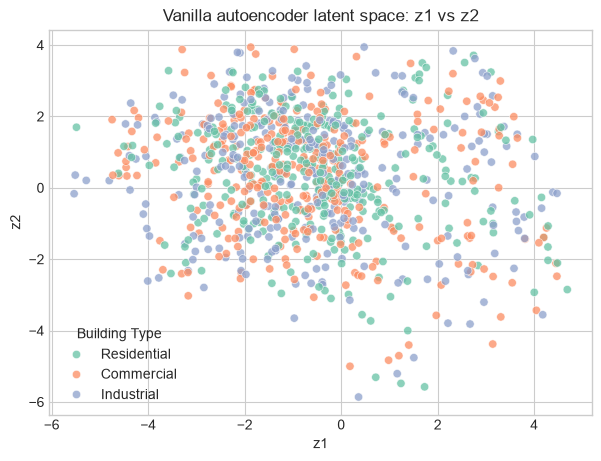

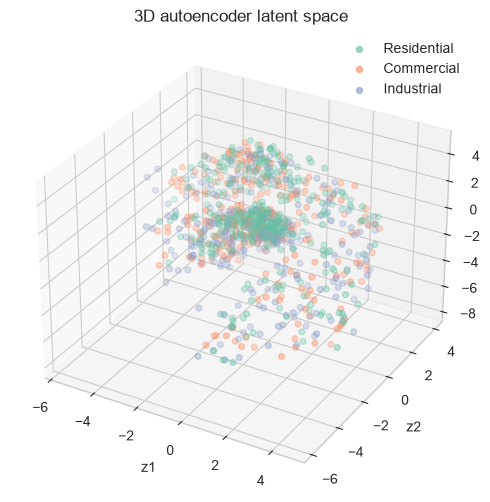

,latent_dim,final_train_loss,train_mse,test_mse
0,1,0.525637,0.522868,0.536316
1,2,0.310388,0.307804,0.347573
2,3,0.148172,0.145625,0.154303
3,6,0.002831,0.002746,0.003410


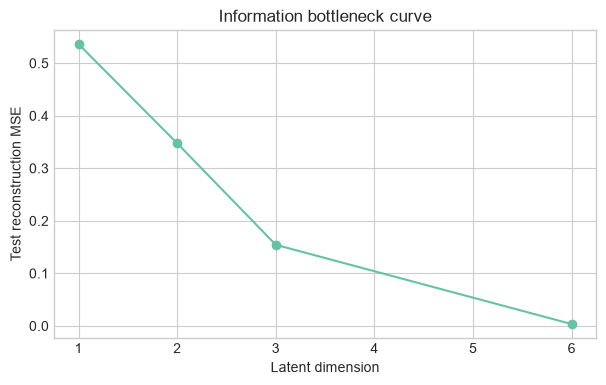

In [5]:
ae.eval()
with torch.no_grad():
    Z_train = ae.encode(X_train_tensor).detach().cpu().numpy()

latent_df = pd.DataFrame(Z_train, columns=['z1', 'z2', 'z3'])
latent_df['Building Type'] = y_train_labels

plt.figure(figsize=(7, 5))
sns.scatterplot(data=latent_df, x='z1', y='z2', hue='Building Type', alpha=0.75)
plt.title('Vanilla autoencoder latent space: z1 vs z2')
plt.show()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
for cls in CLASSES:
    mask = latent_df['Building Type'] == cls
    ax.scatter(latent_df.loc[mask, 'z1'], latent_df.loc[mask, 'z2'], latent_df.loc[mask, 'z3'], label=cls, s=18, alpha=0.65)
ax.set_xlabel('z1')
ax.set_ylabel('z2')
ax.set_zlabel('z3')
ax.set_title('3D autoencoder latent space')
ax.legend()
plt.show()

latent_dim_rows = []
for latent_dim in [1, 2, 3, 6]:
    model = BaseAutoencoder(input_dim=X_train.shape[1], latent_dim=latent_dim)
    history = train_autoencoder(model, train_loader, n_epochs=120, lr=1e-3)
    tr_err, _ = reconstruction_errors(model, X_train_tensor)
    te_err, _ = reconstruction_errors(model, X_test_tensor)
    latent_dim_rows.append({
        'latent_dim': latent_dim,
        'final_train_loss': history[-1],
        'train_mse': tr_err.mean(),
        'test_mse': te_err.mean(),
    })

latent_dim_df = pd.DataFrame(latent_dim_rows)
display(latent_dim_df)
plt.figure(figsize=(7, 4))
plt.plot(latent_dim_df['latent_dim'], latent_dim_df['test_mse'], marker='o')
plt.xlabel('Latent dimension')
plt.ylabel('Test reconstruction MSE')
plt.title('Information bottleneck curve')
plt.show()


**Observation:** The bottleneck curve behaves as expected: test MSE drops from about `0.536` with one latent dimension to about `0.003` with six latent dimensions. The three-dimensional bottleneck is a useful compromise because it compresses the six-feature input while keeping test MSE near `0.154`.


## 4. Anomaly Detection on EnergyTypeNet


,threshold,precision,recall,f1
0,0.493197,0.875,0.233333,0.368421


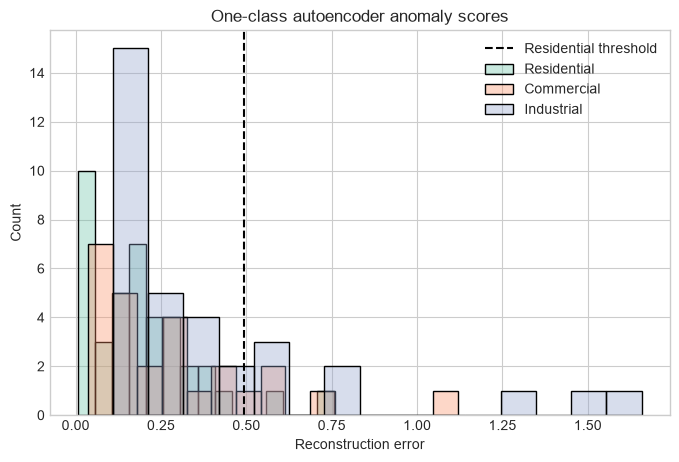

In [6]:
residential_mask = y_train_labels == 'Residential'
X_residential = X_train_tensor[residential_mask]
residential_loader = DataLoader(TensorDataset(X_residential), batch_size=64, shuffle=True)

one_class_ae = BaseAutoencoder(input_dim=X_train.shape[1], latent_dim=3)
one_class_history = train_autoencoder(one_class_ae, residential_loader, n_epochs=200, lr=1e-3)

res_train_errors, _ = reconstruction_errors(one_class_ae, X_residential)
all_test_errors, _ = reconstruction_errors(one_class_ae, X_test_tensor)
threshold = res_train_errors.mean() + 2 * res_train_errors.std()

y_anomaly_true = (y_test_labels != 'Residential').astype(int)
y_anomaly_pred = (all_test_errors > threshold).astype(int)

anomaly_metrics = {
    'threshold': threshold,
    'precision': precision_score(y_anomaly_true, y_anomaly_pred, zero_division=0),
    'recall': recall_score(y_anomaly_true, y_anomaly_pred, zero_division=0),
    'f1': f1_score(y_anomaly_true, y_anomaly_pred, zero_division=0),
}
display(pd.DataFrame([anomaly_metrics]))

error_plot_df = pd.DataFrame({
    'building_type': y_test_labels,
    'reconstruction_error': all_test_errors,
})
plt.figure(figsize=(8, 5))
for cls in CLASSES:
    sns.histplot(error_plot_df.loc[error_plot_df['building_type'] == cls, 'reconstruction_error'], label=cls, alpha=0.35, bins=15)
plt.axvline(threshold, color='black', linestyle='--', label='Residential threshold')
plt.xlabel('Reconstruction error')
plt.title('One-class autoencoder anomaly scores')
plt.legend()
plt.show()


**Observation:** The one-class autoencoder produced high anomaly precision (`0.875`) but low recall (`0.233`). That means when it flags a building as anomalous it is usually right, but it misses many non-Residential examples. This is a conservative detector; lowering the threshold would catch more anomalies at the cost of more false positives.


## 5. Denoising Autoencoder on EnergyTypeNet


,model,input,mse
0,Vanilla AE,clean,0.196552
1,Vanilla AE,noisy,0.396677
2,Denoising AE,clean,0.187152
3,Denoising AE,noisy,0.286284


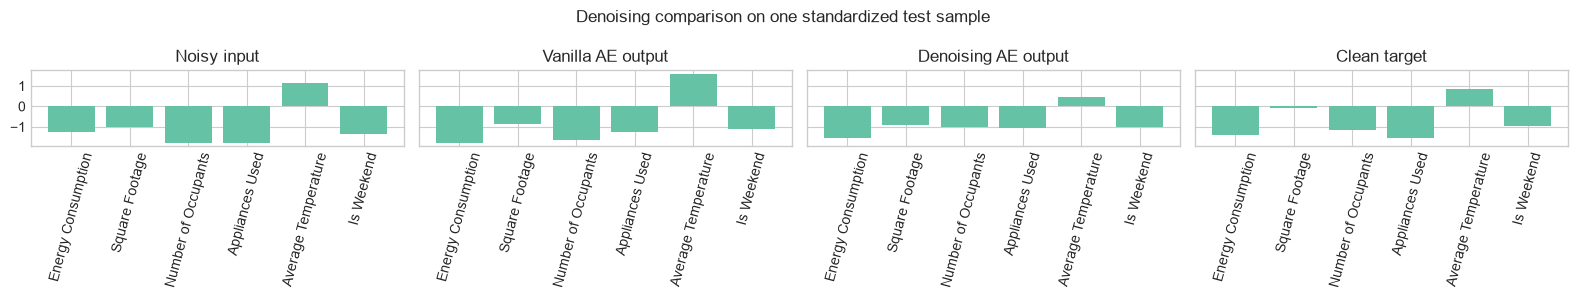

In [7]:
class DenoisingAutoencoder(BaseAutoencoder):
    pass


dae = DenoisingAutoencoder(input_dim=X_train.shape[1], latent_dim=3)
dae_history = train_autoencoder(dae, train_loader, n_epochs=200, lr=1e-3, noise_std=0.5)

noise_std = 0.5
X_test_noisy_tensor = X_test_tensor + torch.randn_like(X_test_tensor) * noise_std

clean_vanilla_errors, clean_vanilla_recon = reconstruction_errors(ae, X_test_tensor)
noisy_vanilla_errors, noisy_vanilla_recon = reconstruction_errors(ae, X_test_noisy_tensor)
clean_dae_errors, clean_dae_recon = reconstruction_errors(dae, X_test_tensor)
noisy_dae_errors, noisy_dae_recon = reconstruction_errors(dae, X_test_noisy_tensor)

denoise_comparison = pd.DataFrame([
    {'model': 'Vanilla AE', 'input': 'clean', 'mse': clean_vanilla_errors.mean()},
    {'model': 'Vanilla AE', 'input': 'noisy', 'mse': noisy_vanilla_errors.mean()},
    {'model': 'Denoising AE', 'input': 'clean', 'mse': clean_dae_errors.mean()},
    {'model': 'Denoising AE', 'input': 'noisy', 'mse': noisy_dae_errors.mean()},
])
display(denoise_comparison)

fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
plot_values = [
    ('Noisy input', X_test_noisy_tensor[0].detach().cpu().numpy()),
    ('Vanilla AE output', noisy_vanilla_recon[0]),
    ('Denoising AE output', noisy_dae_recon[0]),
    ('Clean target', X_test[0]),
]
for ax, (title, values) in zip(axes, plot_values):
    ax.bar(feature_names, values)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=75)
plt.suptitle('Denoising comparison on one standardized test sample')
plt.tight_layout()
plt.show()


**Observation:** The denoising autoencoder improves noisy-input reconstruction substantially: noisy MSE drops from about `0.397` for the vanilla autoencoder to about `0.286`. It also slightly improves clean-input reconstruction, which suggests the noise objective helped the model learn a smoother representation.


## 6. Variational Autoencoder (VAE) - Introduction


A variational autoencoder learns a distribution over latent variables rather than a single deterministic code. The encoder predicts `mu` and `logvar`, then samples with the reparameterization trick:

`z = mu + eps * exp(0.5 * logvar)`, where `eps ~ N(0, I)`.

The loss combines reconstruction quality with KL regularization:

`ELBO loss = reconstruction_loss + beta * KL(q(z|x) || p(z))`

The KL term encourages a smooth latent space that can be sampled from.


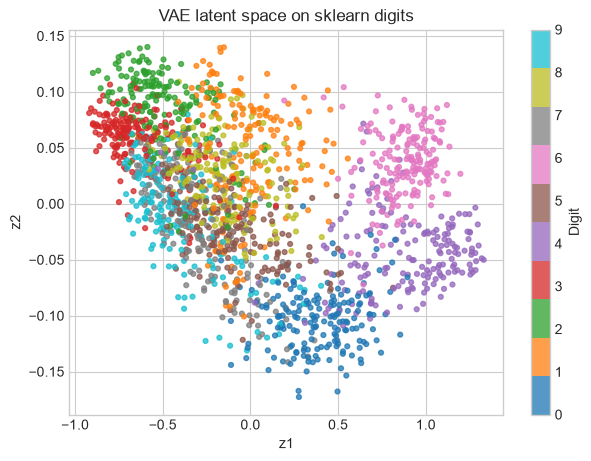

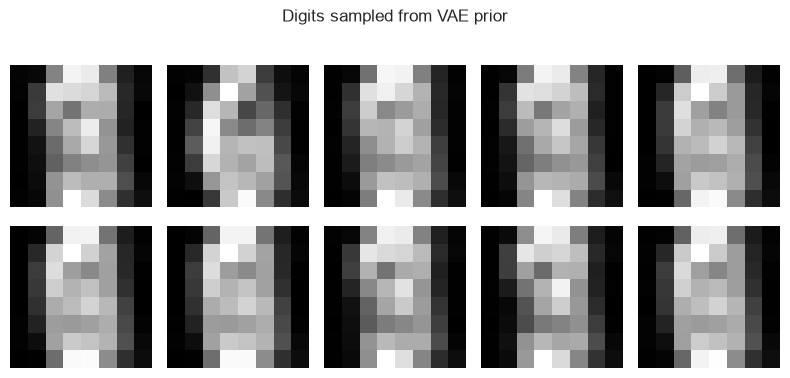

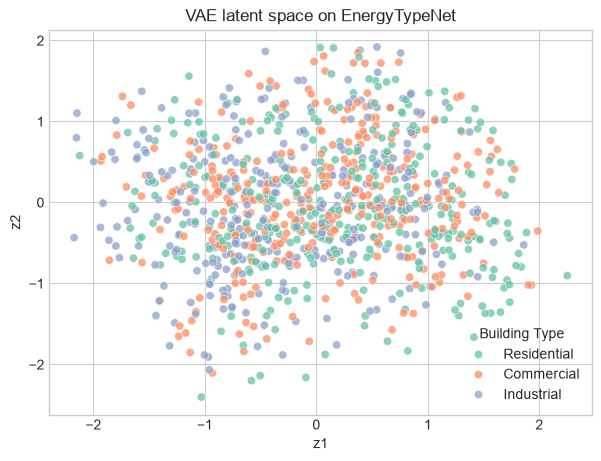

Digits VAE final loss: {'loss': 4.677899070361885, 'reconstruction': 4.486113556239363, 'kl': 0.19178550901450114}
Energy VAE final loss: {'loss': 5.064464569091797, 'reconstruction': 3.874123977661133, 'kl': 1.1903406295776366}


In [8]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=2, hidden_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.mu_layer = nn.Linear(hidden_dim // 2, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim // 2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu_layer(h), self.logvar_layer(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon.detach(), kl.detach()


def train_vae(model, loader, n_epochs=120, lr=1e-3, beta=1.0):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for _ in range(n_epochs):
        model.train()
        total_loss = 0.0
        total_recon = 0.0
        total_kl = 0.0
        n = 0
        for (xb,) in loader:
            optimizer.zero_grad()
            x_hat, mu, logvar = model(xb)
            loss, recon, kl = vae_loss(x_hat, xb, mu, logvar, beta)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            n += len(xb)
        history.append({
            'loss': total_loss / n,
            'reconstruction': total_recon / n,
            'kl': total_kl / n,
        })
    return pd.DataFrame(history)


digits = load_digits()
X_digits = digits.data.astype(np.float32) / 16.0
y_digits = digits.target
digits_tensor = torch.tensor(X_digits, dtype=torch.float32, device=DEVICE)
digits_loader = DataLoader(TensorDataset(digits_tensor), batch_size=128, shuffle=True)

digits_vae = VAE(input_dim=64, latent_dim=2, hidden_dim=64)
digits_vae_history = train_vae(digits_vae, digits_loader, n_epochs=80, lr=1e-3, beta=1.0)

digits_vae.eval()
with torch.no_grad():
    mu_digits, _ = digits_vae.encode(digits_tensor)
    Z_digits = mu_digits.detach().cpu().numpy()
    sampled = digits_vae.decode(torch.randn(10, 2, device=DEVICE)).detach().cpu().numpy()

plt.figure(figsize=(7, 5))
scatter = plt.scatter(Z_digits[:, 0], Z_digits[:, 1], c=y_digits, cmap='tab10', s=12, alpha=0.75)
plt.colorbar(scatter, label='Digit')
plt.title('VAE latent space on sklearn digits')
plt.xlabel('z1')
plt.ylabel('z2')
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for ax, row in zip(axes.ravel(), sampled):
    ax.imshow(row.reshape(8, 8), cmap='gray')
    ax.axis('off')
plt.suptitle('Digits sampled from VAE prior')
plt.tight_layout()
plt.show()

energy_vae = VAE(input_dim=X_train.shape[1], latent_dim=2, hidden_dim=32)
energy_vae_history = train_vae(energy_vae, train_loader, n_epochs=120, lr=1e-3, beta=1.0)
with torch.no_grad():
    mu_energy, _ = energy_vae.encode(X_train_tensor)
    Z_energy_vae = mu_energy.detach().cpu().numpy()

vae_latent_df = pd.DataFrame(Z_energy_vae, columns=['z1', 'z2'])
vae_latent_df['Building Type'] = y_train_labels
plt.figure(figsize=(7, 5))
sns.scatterplot(data=vae_latent_df, x='z1', y='z2', hue='Building Type', alpha=0.75)
plt.title('VAE latent space on EnergyTypeNet')
plt.show()

print('Digits VAE final loss:', digits_vae_history.iloc[-1].to_dict())
print('Energy VAE final loss:', energy_vae_history.iloc[-1].to_dict())


**Observation:** The digits VAE provides the clearest visual example because digit classes have recognizable shape structure. The EnergyTypeNet VAE has a larger KL term (`~1.19`) than the digits VAE (`~0.19`), showing that the tabular latent space is being more strongly regularized while still reconstructing standardized building features.


## 7. Bottleneck Size - Compression Study on EnergyTypeNet


,model,latent_dim,train_mse,test_mse,kl_loss
0,Vanilla AE,1,0.559339,0.582902,NaN
1,VAE,1,4.363508,0.741115,0.796904
2,Vanilla AE,2,0.270520,0.354028,NaN
3,VAE,2,3.685225,0.639211,1.285047
4,Vanilla AE,3,0.205035,0.223648,NaN
5,VAE,3,3.395818,0.591929,1.438502
6,Vanilla AE,4,0.018064,0.021240,NaN
7,VAE,4,3.027053,0.477595,1.776042
8,Vanilla AE,6,0.017817,0.021472,NaN
9,VAE,6,3.192203,0.491658,1.671377


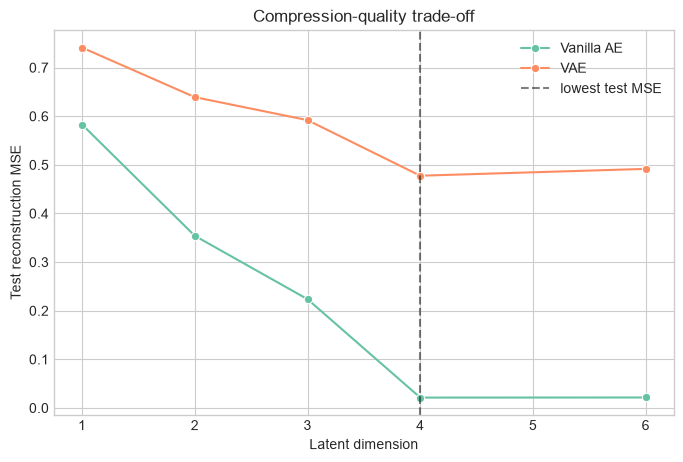

In [9]:
compression_rows = []
for latent_dim in [1, 2, 3, 4, 6]:
    base = BaseAutoencoder(input_dim=X_train.shape[1], latent_dim=latent_dim)
    train_autoencoder(base, train_loader, n_epochs=100, lr=1e-3)
    tr_err, _ = reconstruction_errors(base, X_train_tensor)
    te_err, _ = reconstruction_errors(base, X_test_tensor)
    compression_rows.append({
        'model': 'Vanilla AE',
        'latent_dim': latent_dim,
        'train_mse': tr_err.mean(),
        'test_mse': te_err.mean(),
        'kl_loss': np.nan,
    })

    vae = VAE(input_dim=X_train.shape[1], latent_dim=latent_dim, hidden_dim=32)
    hist = train_vae(vae, train_loader, n_epochs=100, lr=1e-3, beta=1.0)
    vae.eval()
    with torch.no_grad():
        recon, mu, logvar = vae(X_test_tensor)
        test_mse = ((X_test_tensor - recon) ** 2).mean(dim=1).detach().cpu().numpy().mean()
    compression_rows.append({
        'model': 'VAE',
        'latent_dim': latent_dim,
        'train_mse': hist.iloc[-1]['reconstruction'],
        'test_mse': test_mse,
        'kl_loss': hist.iloc[-1]['kl'],
    })

compression_df = pd.DataFrame(compression_rows)
display(compression_df)

plt.figure(figsize=(8, 5))
sns.lineplot(data=compression_df, x='latent_dim', y='test_mse', hue='model', marker='o')
best_row = compression_df.sort_values('test_mse').iloc[0]
plt.axvline(best_row['latent_dim'], color='black', linestyle='--', alpha=0.5, label='lowest test MSE')
plt.xlabel('Latent dimension')
plt.ylabel('Test reconstruction MSE')
plt.title('Compression-quality trade-off')
plt.legend()
plt.show()


**Observation:** Vanilla autoencoders reconstruct EnergyTypeNet more accurately than VAEs in this setup because VAEs trade reconstruction quality for a smoother probabilistic latent space. The vanilla model reaches very low test MSE by latent dimension 4, while the VAE remains higher because of KL regularization.


## 8. Autoencoder as Feature Extractor on EnergyTypeNet


In [10]:
with torch.no_grad():
    Z_train_ae = ae.encode(X_train_tensor).detach().cpu().numpy()
    Z_test_ae = ae.encode(X_test_tensor).detach().cpu().numpy()

pca = PCA(n_components=3, random_state=RANDOM_STATE)
Z_train_pca = pca.fit_transform(X_train)
Z_test_pca = pca.transform(X_test)

lda = LinearDiscriminantAnalysis(n_components=2)
Z_train_lda = lda.fit_transform(X_train, y_train)
Z_test_lda = lda.transform(X_test)

feature_sets = [
    ('Raw standardized features', X_train, X_test),
    ('Autoencoder latent(3)', Z_train_ae, Z_test_ae),
    ('PCA(3)', Z_train_pca, Z_test_pca),
    ('LDA(2)', Z_train_lda, Z_test_lda),
]

extractor_rows = []
for name, Xtr, Xte in feature_sets:
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    extractor_rows.append({
        'feature_source': name,
        'n_features': Xtr.shape[1],
        'test_accuracy': accuracy_score(y_test, pred),
        'macro_f1': f1_score(y_test, pred, average='macro'),
    })

extractor_df = pd.DataFrame(extractor_rows).sort_values('test_accuracy', ascending=False)
display(extractor_df)


,feature_source,n_features,test_accuracy,macro_f1
0,Raw standardized features,6,1.00,1.000000
1,Autoencoder latent(3),3,0.39,0.357654
3,LDA(2),2,0.36,0.328740
2,PCA(3),3,0.35,0.319821


**Observation:** Raw standardized features dominate the supervised classification comparison with `1.000` test accuracy. Autoencoder, PCA and LDA compressed features are much weaker here, so the autoencoder is more valuable for reconstruction/anomaly detection than for replacing the original supervised feature set on this small dataset.


## 9. Summary Table


In [11]:
summary_rows = [
    {
        'Model': 'Vanilla AE',
        'Dataset': 'EnergyTypeNet',
        'Latent dim': 3,
        'Train MSE': train_errors.mean(),
        'Test MSE': test_errors.mean(),
        'Notes': 'Baseline reconstruction model',
    },
    {
        'Model': 'Denoising AE',
        'Dataset': 'EnergyTypeNet',
        'Latent dim': 3,
        'Train MSE': dae_history[-1],
        'Test MSE': noisy_dae_errors.mean(),
        'Notes': 'Trained on noisy inputs and clean targets',
    },
    {
        'Model': 'VAE',
        'Dataset': 'Digits',
        'Latent dim': 2,
        'Train MSE': digits_vae_history.iloc[-1]['reconstruction'],
        'Test MSE': np.nan,
        'Notes': 'Supplementary image-like latent visualization',
    },
    {
        'Model': 'VAE',
        'Dataset': 'EnergyTypeNet',
        'Latent dim': 2,
        'Train MSE': energy_vae_history.iloc[-1]['reconstruction'],
        'Test MSE': compression_df.query("model == 'VAE' and latent_dim == 2")['test_mse'].iloc[0],
        'Notes': 'Smooth tabular latent representation',
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,Model,Dataset,Latent dim,Train MSE,Test MSE,Notes
0,Vanilla AE,EnergyTypeNet,3,0.131184,0.196552,Baseline reconstruction model
1,Denoising AE,EnergyTypeNet,3,0.289141,0.286284,Trained on noisy inputs and clean targets
2,VAE,Digits,2,4.486114,NaN,Supplementary image-like latent visualization
3,VAE,EnergyTypeNet,2,3.874124,0.639211,Smooth tabular latent representation


## Key Takeaways

- Autoencoders make EnergyTypeNet useful for unsupervised reconstruction, compression and anomaly detection.
- A one-class autoencoder trained only on Residential buildings can act as a novelty detector for unusual building patterns.
- Denoising autoencoders are better aligned with noisy sensor data because they learn to map corrupted inputs back to clean patterns.
- VAEs add a probabilistic latent space, which is useful when smooth sampling or interpolation matters.
- Autoencoder latent features are not guaranteed to beat supervised features on small labeled datasets, but they become valuable when labels are scarce or when anomaly scoring is the goal.
